In [ ]:
import pandas as pd

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login',
    'count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

train_df = pd.read_csv("KDDTrain+.txt", names=columns)
test_df  = pd.read_csv("KDDTest+.txt", names=columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (125973, 43)
Test shape: (22544, 43)


In [ ]:
# Step 1: Check label distribution
train_df['label'].value_counts().head(10)

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


In [ ]:
# Step 2: Binary classification (Normal vs Attack)
train_df['binary_label'] = train_df['label'].apply(
    lambda x: 0 if x == 'normal' else 1
)

train_df['binary_label'].value_counts()

,count
binary_label,
0,67343
1,58630


In [ ]:
# Step 3: One-hot encode categorical features
categorical_cols = ['protocol_type', 'service', 'flag']

train_df_encoded = pd.get_dummies(
    train_df,
    columns=categorical_cols
)

print("Shape after encoding:", train_df_encoded.shape)

Shape after encoding: (125973, 125)


In [ ]:
# Step 4: Separate features and target
X = train_df_encoded.drop(['label', 'binary_label', 'difficulty'], axis=1)
y = train_df_encoded['binary_label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (125973, 122)
y shape: (125973,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (100778, 122)
X_test: (25195, 122)
y_train: (100778,)
y_test: (25195,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (100778, 122)
Scaled X_test shape: (25195, 122)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9722960904941457

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97     13469
           1       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195


Confusion Matrix:
 [[13199   270]
 [  428 11298]]


In [ ]:
import numpy as np

# Convert to numpy arrays (sometimes they're already numpy)
X_train_cnn = np.array(X_train_scaled).reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn  = np.array(X_test_scaled).reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("X_train_cnn:", X_train_cnn.shape)
print("X_test_cnn:", X_test_cnn.shape)

X_train_cnn: (100778, 122, 1)
X_test_cnn: (25195, 122, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization

In [ ]:
model = Sequential()

# CNN layers
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(122, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# LSTM layer
model.add(LSTM(64))

# Dense layers
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 120, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 120, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 58, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 58, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 29, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,873 (140.13 KB)

 Trainable params: 35,681 (139.38 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
history = model.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
315/315 ━━━━━━━━━━━━━━━━━━━━ 58s 163ms/step - accuracy: 0.9328 - loss: 0.1993 - val_accuracy: 0.5417 - val_loss: 0.9091
Epoch 2/5
315/315 ━━━━━━━━━━━━━━━━━━━━ 84s 171ms/step - accuracy: 0.9860 - loss: 0.0434 - val_accuracy: 0.9856 - val_loss: 0.0387
Epoch 3/5
315/315 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.9907 - loss: 0.0283 - val_accuracy: 0.9881 - val_loss: 0.0375
Epoch 4/5
315/315 ━━━━━━━━━━━━━━━━━━━━ 53s 167ms/step - accuracy: 0.9931 - loss: 0.0220 - val_accuracy: 0.9867 - val_loss: 0.0435
Epoch 5/5
315/315 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.9932 - loss: 0.0209 - val_accuracy: 0.9943 - val_loss: 0.0192


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     13469
           1       0.99      1.00      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195

[[13383    86]
 [   57 11669]]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

# Predict probabilities → convert to 0/1
y_pred_prob = model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score  :", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

788/788 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step
Accuracy : 0.9943242706886287
Precision: 0.9926839642705232
Recall   : 0.9951390073341293
F1-score  : 0.9939099697627869

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     13469
           1       0.99      1.00      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195


Confusion Matrix:
 [[13383    86]
 [   57 11669]]


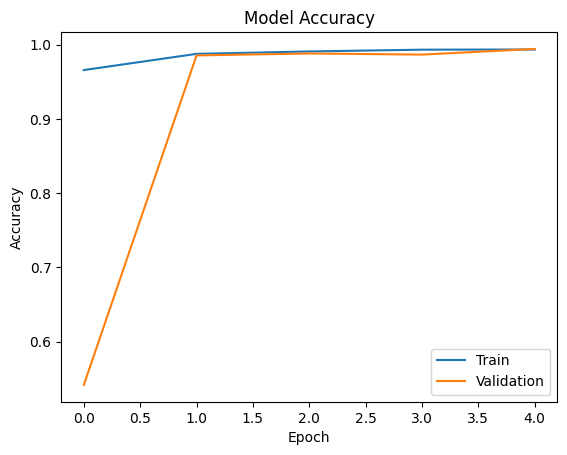

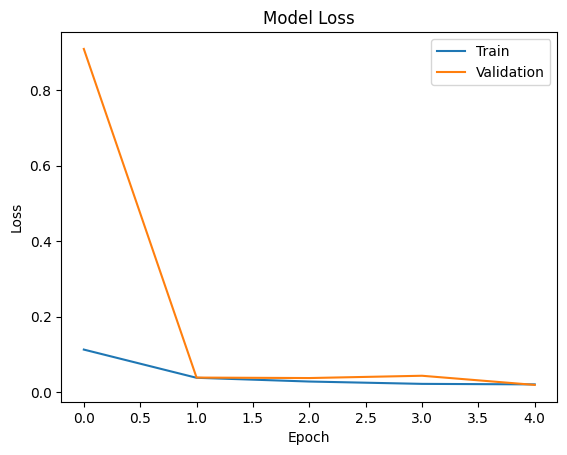

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:

results = {
    "Model": ["Logistic Regression", "CNN-LSTM"],
    "Accuracy": [0.9722, accuracy_score(y_test, y_pred)],  # replace 0.9722 with your LR accuracy
}

import pandas as pd
pd.DataFrame(results)

,Model,Accuracy
0,Logistic Regression,0.972200
1,CNN-LSTM,0.994324
